In [1]:
import pandas as pd
import mysql.connector
from typing import Literal
from DATA.stock_invest_function import get_db_host

In [3]:
def get_ranked_indicator(
    db_info: dict,
    date: str,
    indicator: str,
    order: Literal['desc', 'asc'] = 'desc',
    top_n: int = None
) -> pd.DataFrame:
    """
    한국 재무제표 데이터에서 특정 날짜의 지표를 기준으로 정렬하여 추출

    Parameters:
    -----------
    db_info : dict
        데이터베이스 연결 정보 {'host', 'user', 'password', 'database'}
    date : str
        조회할 날짜 (형식: 'YYYY-MM-DD')
    indicator : str
        조회할 지표명 (예: 'ROE', 'ROA', 'NIM_ttm' 등)
    order : str
        정렬 순서 ('desc': 내림차순, 'asc': 오름차순)
    top_n : int, optional
        상위 n개만 추출 (None이면 전체)

    Returns:
    --------
    pd.DataFrame
        정렬된 결과 데이터프레임
    """

    # 데이터베이스 연결
    conn = mysql.connector.connect(**db_info)

    try:
        # SQL 쿼리 작성
        order_clause = "DESC" if order == 'desc' else "ASC"
        limit_clause = f"LIMIT {top_n}" if top_n else ""

        query = f"""
        SELECT
            date,
            ticker,
            indicator,
            value
        FROM korea_fs_data_roe_roa
        WHERE date = %s
          AND indicator = %s
          AND value IS NOT NULL
        ORDER BY value {order_clause}
        {limit_clause}
        """

        # 쿼리 실행
        df = pd.read_sql(query, conn, params=(date, indicator))

        # 결과 출력
        print(f"\n{'='*60}")
        print(f"날짜: {date} | 지표: {indicator} | 정렬: {order}")
        print(f"총 {len(df)}개 종목")
        print(f"{'='*60}\n")

        return df

    finally:
        conn.close()


In [5]:
# 데이터베이스 연결 정보
db_info = {
    'host': get_db_host(),
    'port': 3307,
    'user' : 'stox7412',
    'password' : 'Apt106503!~',
    'database': 'investar'
}

# 예시 1: 2005-09-30 ROE 상위 20개
result = get_ranked_indicator(
    db_info=db_info,
    date='2025-09-30',
    indicator='ROE',
    order='desc',
    top_n=100
)
print(result)

# # 예시 2: 2005-09-30 ROA 전체 (내림차순)
# result = get_ranked_indicator(
#     db_info=db_info,
#     date='2005-09-30',
#     indicator='ROA',
#     order='desc'
# )
# print(result.head(10))
#
# # 예시 3: 영업이익률 하위 10개
# result = get_ranked_indicator(
#     db_info=db_info,
#     date='2005-09-30',
#     indicator='영업이익_ttm',
#     order='asc',
#     top_n=10
# )
# print(result)


날짜: 2025-09-30 | 지표: ROE | 정렬: desc
총 100개 종목

          date  ticker indicator     value
0   2025-09-30  278470       ROE  0.743452
1   2025-09-30  257720       ROE  0.513932
2   2025-09-30  483650       ROE  0.488816
3   2025-09-30  083650       ROE  0.449141
4   2025-09-30  196170       ROE  0.443503
..         ...     ...       ...       ...
95  2025-09-30  194700       ROE  0.161656
96  2025-09-30  042000       ROE  0.161464
97  2025-09-30  037460       ROE  0.160006
98  2025-09-30  083930       ROE  0.159680
99  2025-09-30  101490       ROE  0.157523

[100 rows x 4 columns]


In [7]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from typing import List, Optional
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows 환경)
try:
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font_name)
except:
    print("한글 폰트 설정 실패. 기본 폰트 사용")

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


def get_timeseries_data(
    db_info: dict,
    ticker: str,
    indicator: str,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None
) -> pd.DataFrame:
    """
    특정 티커의 지표 시계열 데이터 추출

    Parameters:
    -----------
    db_info : dict
        데이터베이스 연결 정보
    ticker : str
        종목 코드
    indicator : str
        지표명
    start_date : str, optional
        시작 날짜 (형식: 'YYYY-MM-DD')
    end_date : str, optional
        종료 날짜 (형식: 'YYYY-MM-DD')

    Returns:
    --------
    pd.DataFrame
        시계열 데이터프레임
    """

    conn = mysql.connector.connect(**db_info)

    try:
        # 기본 쿼리
        query = """
        SELECT
            date,
            ticker,
            indicator,
            value
        FROM korea_fs_data_roe_roa
        WHERE ticker = %s
          AND indicator = %s
          AND value IS NOT NULL
        """

        params = [ticker, indicator]

        # 날짜 필터 추가
        if start_date:
            query += " AND date >= %s"
            params.append(start_date)
        if end_date:
            query += " AND date <= %s"
            params.append(end_date)

        query += " ORDER BY date ASC"

        # 쿼리 실행
        df = pd.read_sql(query, conn, params=params)

        if len(df) == 0:
            print(f"\n경고: 티커 {ticker}, 지표 {indicator}에 대한 데이터가 없습니다.")
            return df

        # date를 datetime으로 변환
        df['date'] = pd.to_datetime(df['date'])

        # 결과 출력
        print(f"\n{'='*60}")
        print(f"티커: {ticker} | 지표: {indicator}")
        print(f"기간: {df['date'].min().strftime('%Y-%m-%d')} ~ {df['date'].max().strftime('%Y-%m-%d')}")
        print(f"데이터 포인트: {len(df)}개")
        print(f"{'='*60}\n")

        return df

    finally:
        conn.close()


def plot_timeseries(
    df: pd.DataFrame,
    title: Optional[str] = None,
    figsize: tuple = (12, 6),
    show_grid: bool = True,
    save_path: Optional[str] = None
):
    """
    시계열 데이터 시각화

    Parameters:
    -----------
    df : pd.DataFrame
        시계열 데이터프레임 (date, value 컬럼 필요)
    title : str, optional
        그래프 제목
    figsize : tuple
        그래프 크기
    show_grid : bool
        그리드 표시 여부
    save_path : str, optional
        저장 경로 (예: 'output.png')
    """

    if len(df) == 0:
        print("데이터가 없어 그래프를 그릴 수 없습니다.")
        return

    fig, ax = plt.subplots(figsize=figsize)

    # 라인 플롯
    ax.plot(df['date'], df['value'], marker='o', linewidth=2, markersize=4)

    # 제목 설정
    if title is None:
        ticker = df['ticker'].iloc[0] if 'ticker' in df.columns else ''
        indicator = df['indicator'].iloc[0] if 'indicator' in df.columns else ''
        title = f"{ticker} - {indicator} 시계열"

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('날짜', fontsize=12)
    ax.set_ylabel('값', fontsize=12)

    # 그리드
    if show_grid:
        ax.grid(True, alpha=0.3, linestyle='--')

    # x축 날짜 포맷 조정
    fig.autofmt_xdate()

    plt.tight_layout()

    # 저장
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"그래프가 {save_path}에 저장되었습니다.")

    plt.show()


def plot_multiple_timeseries(
    db_info: dict,
    ticker: str,
    indicators: List[str],
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    figsize: tuple = (14, 8),
    save_path: Optional[str] = None
):
    """
    여러 지표를 한 번에 시각화 (subplot 사용)

    Parameters:
    -----------
    db_info : dict
        데이터베이스 연결 정보
    ticker : str
        종목 코드
    indicators : List[str]
        지표명 리스트
    start_date : str, optional
        시작 날짜
    end_date : str, optional
        종료 날짜
    figsize : tuple
        그래프 크기
    save_path : str, optional
        저장 경로
    """

    n_indicators = len(indicators)
    n_cols = 2
    n_rows = (n_indicators + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_indicators > 1 else [axes]

    for idx, indicator in enumerate(indicators):
        # 데이터 추출
        df = get_timeseries_data(db_info, ticker, indicator, start_date, end_date)

        if len(df) == 0:
            axes[idx].text(0.5, 0.5, f'데이터 없음\n({indicator})',
                          ha='center', va='center', fontsize=12)
            axes[idx].set_title(indicator, fontweight='bold')
            continue

        # 플롯
        axes[idx].plot(df['date'], df['value'], marker='o', linewidth=2, markersize=3)
        axes[idx].set_title(indicator, fontweight='bold', fontsize=11)
        axes[idx].grid(True, alpha=0.3, linestyle='--')
        axes[idx].tick_params(axis='x', rotation=45)

    # 빈 subplot 제거
    for idx in range(n_indicators, len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle(f'{ticker} 재무지표 시계열', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"그래프가 {save_path}에 저장되었습니다.")

    plt.show()

In [13]:
# 예시 1: 단일 지표 시계열 추출 및 시각화
print("\n=== 예시 1: 단일 지표 시계열 ===")
df_roe = get_timeseries_data(
    db_info=db_info,
    ticker='065710',
    indicator='ROE',
    start_date='2000-01-01',
    end_date='2025-09-30'
)

print(df_roe.head())
print(f"\n기초 통계량:\n{df_roe['value'].describe()}")


=== 예시 1: 단일 지표 시계열 ===

티커: 065710 | 지표: ROE
기간: 2005-03-31 ~ 2025-09-30
데이터 포인트: 77개

        date  ticker indicator     value
0 2005-03-31  065710       ROE  0.226714
1 2005-06-30  065710       ROE  0.238397
2 2005-09-30  065710       ROE  0.270722
3 2005-12-31  065710       ROE  0.310089
4 2006-03-31  065710       ROE  0.358452

기초 통계량:
count    77.000000
mean      0.160363
std       0.129474
min       0.013875
25%       0.064111
50%       0.143623
75%       0.215051
max       0.604981
Name: value, dtype: float64


그래프가 roe_timeseries.png에 저장되었습니다.


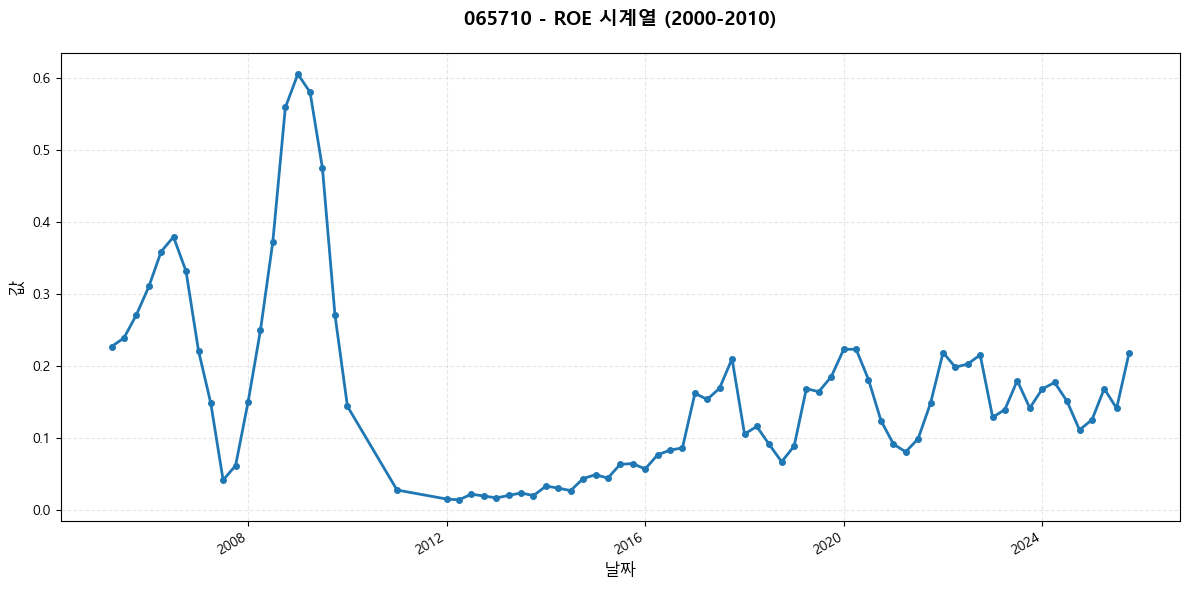

In [14]:
# 시각화
plot_timeseries(
    df=df_roe,
    title='065710 - ROE 시계열 (2000-2010)',
    save_path='roe_timeseries.png'
)


=== 예시 2: 여러 지표 동시 시각화 ===

티커: 065710 | 지표: ROE
기간: 2005-03-31 ~ 2025-09-30
데이터 포인트: 77개


티커: 065710 | 지표: ROA
기간: 2005-03-31 ~ 2025-09-30
데이터 포인트: 77개


티커: 065710 | 지표: NIM_ttm
기간: 2004-12-31 ~ 2025-09-30
데이터 포인트: 84개


티커: 065710 | 지표: OPM_ttm
기간: 2004-12-31 ~ 2025-09-30
데이터 포인트: 84개

그래프가 multiple_indicators.png에 저장되었습니다.


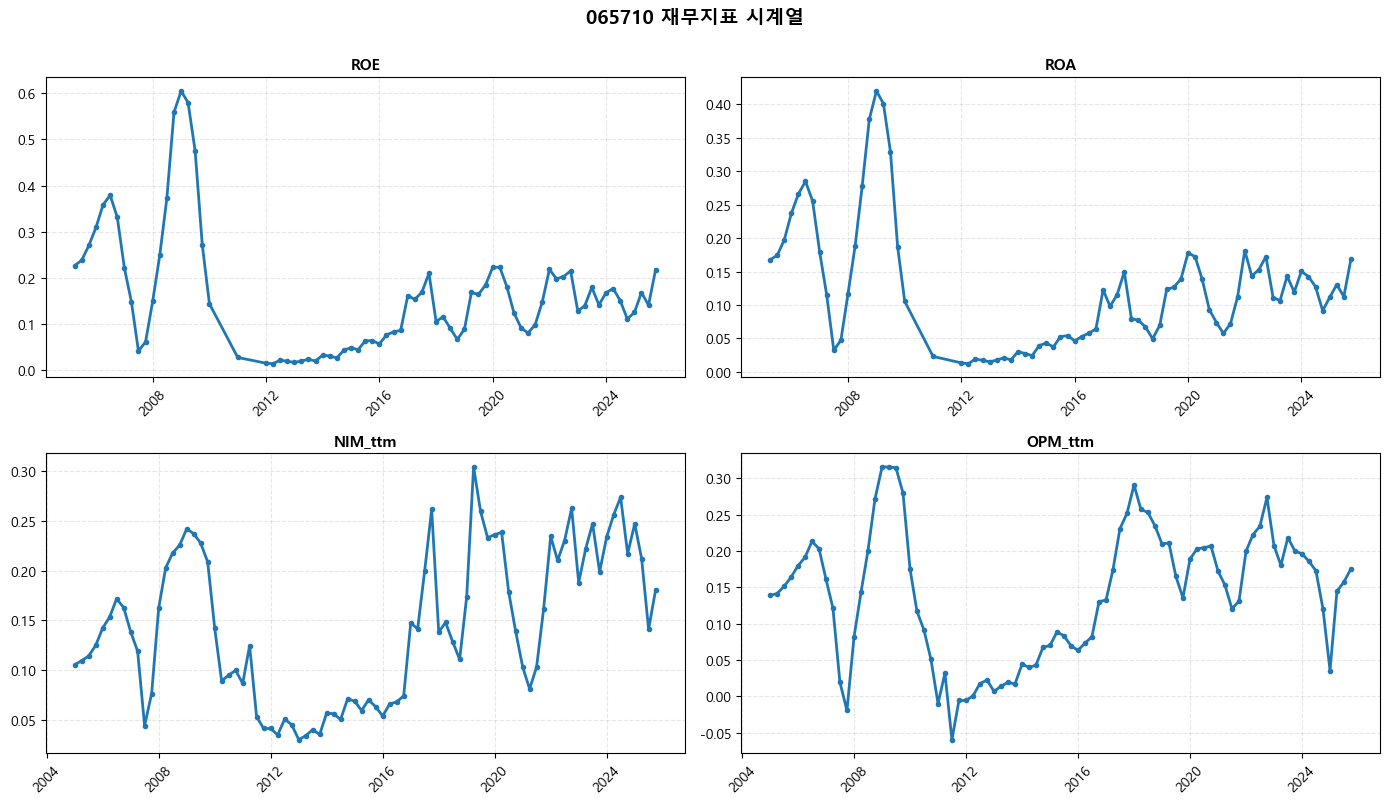

In [15]:
# 예시 2: 여러 지표 동시 시각화
print("\n=== 예시 2: 여러 지표 동시 시각화 ===")
indicators = ['ROE', 'ROA', 'NIM_ttm', 'OPM_ttm']

plot_multiple_timeseries(
    db_info=db_info,
    ticker='065710',
    indicators=indicators,
    start_date='2000-01-01',
    end_date='2025-09-30',
    save_path='multiple_indicators.png'
)


=== 예시 3: 최근 5년 데이터 ===

티커: 000660 | 지표: 영업이익_ttm
기간: 2025-03-31 ~ 2025-09-30
데이터 포인트: 3개



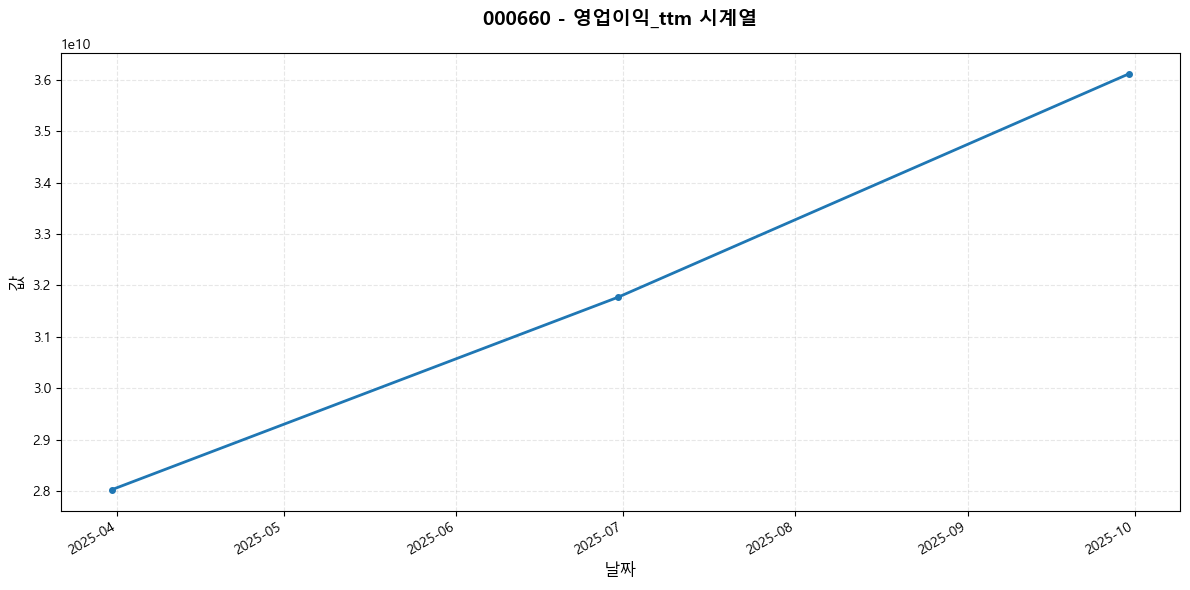

In [12]:
# 예시 3: 최근 데이터만 추출
print("\n=== 예시 3: 최근 5년 데이터 ===")
df_recent = get_timeseries_data(
    db_info=db_info,
    ticker='000660',
    indicator='영업이익_ttm',
    start_date='2025-01-01'
)

plot_timeseries(df_recent)